In [ ]:
pip install ta yahooquery

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from yahooquery import Ticker
import ta
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
tf.random.set_seed(42)

In [ ]:
ticker = Ticker("RELIANCE.NS")
r_stock = ticker.history(start="2008-01-01", end="2025-4-01", interval="1d")
r_stock

/usr/local/lib/python3.11/dist-packages/yahooquery/utils/__init__.py:1470: FutureWarning: 'S' is deprecated and will be removed in a future version. Please use 's' instead of 'S'.
  has_live_indice = index_utc[-1] >= last_trade - pd.Timedelta(2, "S")
/usr/local/lib/python3.11/dist-packages/yahooquery/ticker.py:1333: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["dividends"].fillna(0, inplace=True)
/usr/local/lib/python3.11/dist-packages/yahooquery/ticker.py:1335: FutureWarning: A value is trying to be set on a copy of a Dat

open         high          low        close  \
symbol      date                                                             
RELIANCE.NS 2008-01-01   330.302704   331.331329   324.028076   325.531006   
            2008-01-02   326.302490   329.616943   321.307953   327.073944   
            2008-01-03   325.959625   334.874359   323.473755   331.868500   
            2008-01-04   331.902771   345.137726   331.902771   342.074738   
            2008-01-07   339.994629   346.303528   338.303101   345.189178   
...                             ...          ...          ...          ...   
            2025-03-24  1275.000000  1281.000000  1270.099976  1276.349976   
            2025-03-25  1291.000000  1306.000000  1284.250000  1302.099976   
            2025-03-26  1307.699951  1307.699951  1282.599976  1285.449951   
            2025-03-27  1291.000000  1293.800049  1268.750000  1273.050049   
            2025-03-28  1278.150024  1285.000000  1271.300049  1278.199951   

                            volume     adjclose  dividends  splits  
symbol      date                                                    
RELIANCE.NS 2008-01-01  10540548.0   302.673126        0.0     0.0  
            2008-01-02  27276294.0   304.107758        0.0     0.0  
            2008-01-03  30204199.0   308.565674        0.0     0.0  
            2008-01-04  35463186.0   318.055267        0.0     0.0  
            2008-01-07  27412209.0   320.951019        0.0     0.0  
...                            ...          ...        ...     ...  
            2025-03-24  21780769.0  1276.349976        0.0     0.0  
            2025-03-25  20299319.0  1302.099976        0.0     0.0  
            2025-03-26  13713899.0  1285.449951        0.0     0.0  
            2025-03-27  12074747.0  1273.050049        0.0     0.0  
            2025-03-28  15028056.0  1278.199951        0.0     0.0  

[4250 rows x 8 columns]

In [ ]:
ticker = Ticker("TCS.NS")
t_stock = ticker.history(start="2008-01-01", end="2025-4-01", interval="1d")
t_stock

/usr/local/lib/python3.11/dist-packages/yahooquery/utils/__init__.py:1470: FutureWarning: 'S' is deprecated and will be removed in a future version. Please use 's' instead of 'S'.
  has_live_indice = index_utc[-1] >= last_trade - pd.Timedelta(2, "S")
/usr/local/lib/python3.11/dist-packages/yahooquery/ticker.py:1333: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["dividends"].fillna(0, inplace=True)
/usr/local/lib/python3.11/dist-packages/yahooquery/ticker.py:1335: FutureWarning: A value is trying to be set on a copy of a Dat

open         high          low        close  \
symbol date                                                             
TCS.NS 2008-01-01   269.250000   269.250000   263.000000   263.637512   
       2008-01-02   265.000000   265.250000   257.875000   262.500000   
       2008-01-03   257.524994   261.250000   251.337494   252.762497   
       2008-01-04   252.762497   255.725006   250.574997   251.300003   
       2008-01-07   250.000000   252.199997   243.125000   243.899994   
...                        ...          ...          ...          ...   
       2025-03-24  3475.000000  3616.250000  3465.000000  3578.100098   
       2025-03-25  3600.000000  3649.750000  3566.600098  3628.949951   
       2025-03-26  3645.000000  3710.000000  3638.000000  3657.750000   
       2025-03-27  3647.750000  3680.500000  3625.850098  3635.800049   
       2025-03-28  3614.850098  3663.000000  3610.500000  3651.199951   

                      volume     adjclose  dividends  splits  
symbol date                                                   
TCS.NS 2008-01-01   928388.0   196.386307        0.0     0.0  
       2008-01-02  2864924.0   195.539017        0.0     0.0  
       2008-01-03  5168280.0   188.285446        0.0     0.0  
       2008-01-04  2318868.0   187.195923        0.0     0.0  
       2008-01-07  3647344.0   181.683655        0.0     0.0  
...                      ...          ...        ...     ...  
       2025-03-24  4161925.0  3578.100098        0.0     0.0  
       2025-03-25  1834751.0  3628.949951        0.0     0.0  
       2025-03-26  3135390.0  3657.750000        0.0     0.0  
       2025-03-27  1734499.0  3635.800049        0.0     0.0  
       2025-03-28  2528474.0  3651.199951        0.0     0.0  

[4250 rows x 8 columns]

In [ ]:
ticker = Ticker("HDFCBANK.NS")
h_stock = ticker.history(start="2008-01-01", end="2025-4-01", interval="1d")
h_stock

/usr/local/lib/python3.11/dist-packages/yahooquery/utils/__init__.py:1470: FutureWarning: 'S' is deprecated and will be removed in a future version. Please use 's' instead of 'S'.
  has_live_indice = index_utc[-1] >= last_trade - pd.Timedelta(2, "S")
/usr/local/lib/python3.11/dist-packages/yahooquery/ticker.py:1333: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["dividends"].fillna(0, inplace=True)
/usr/local/lib/python3.11/dist-packages/yahooquery/ticker.py:1335: FutureWarning: A value is trying to be set on a copy of a Dat

open         high          low        close  \
symbol      date                                                             
HDFCBANK.NS 2008-01-01   173.000000   173.899994   170.500000   172.949997   
            2008-01-02   173.399994   173.479996   169.029999   171.529999   
            2008-01-03   171.000000   171.000000   167.619995   169.440002   
            2008-01-04   170.300003   171.399994   169.399994   169.639999   
            2008-01-07   165.100006   167.839996   161.229996   165.539993   
...                             ...          ...          ...          ...   
            2025-03-24  1755.550049  1774.099976  1755.550049  1770.349976   
            2025-03-25  1779.000000  1804.400024  1773.650024  1800.000000   
            2025-03-26  1804.900024  1843.699951  1801.500000  1821.449951   
            2025-03-27  1825.000000  1827.500000  1802.000000  1806.550049   
            2025-03-28  1800.000000  1841.000000  1798.099976  1825.349976   

                            volume     adjclose  dividends  splits  
symbol      date                                                    
HDFCBANK.NS 2008-01-01   1310520.0   152.192703        0.0     0.0  
            2008-01-02   6239750.0   150.943100        0.0     0.0  
            2008-01-03   7018640.0   149.103958        0.0     0.0  
            2008-01-04   3729820.0   149.279984        0.0     0.0  
            2008-01-07   6322460.0   145.672058        0.0     0.0  
...                            ...          ...        ...     ...  
            2025-03-24  16754132.0  1770.349976        0.0     0.0  
            2025-03-25   8696868.0  1800.000000        0.0     0.0  
            2025-03-26  19550708.0  1821.449951        0.0     0.0  
            2025-03-27  12239221.0  1806.550049        0.0     0.0  
            2025-03-28  20829050.0  1825.349976        0.0     0.0  

[4250 rows x 8 columns]

In [ ]:
t_stock.to_csv("Reliance_stock_data.csv")
print("Data saved successfully!")

Data saved successfully!


In [ ]:
t_stock.to_csv("TCS_stock_data.csv")
print("Data saved successfully!")

Data saved successfully!


In [ ]:
h_stock.to_csv("HDFCbank_stock_data.csv")
print("Data saved successfully!")

Data saved successfully!


In [ ]:
# Function to load and preprocess stock data
def load_and_preprocess(filepath):
    stock = pd.read_csv(filepath)
    stock['RSI_14'] = ta.momentum.RSIIndicator(stock['close'], window=14).rsi()
    stock['EMA_12'] = stock['close'].ewm(span=12, adjust=False).mean()
    stock['EMA_26'] = stock['close'].ewm(span=26, adjust=False).mean()
    stock['MACD'] = stock['EMA_12'] - stock['EMA_26']
    stock['Signal_Line'] = stock['MACD'].ewm(span=9, adjust=False).mean()
    stock['SMA'] = stock['close'].rolling(window=20).mean()
    stock['Upper_Band'] = stock['SMA'] + (2 * stock['close'].rolling(window=20).std())
    stock['Lower_Band'] = stock['SMA'] - (2 * stock['close'].rolling(window=20).std())

    stock['ATR'] = ta.volatility.AverageTrueRange(
        high=stock['high'],
        low=stock['low'],
        close=stock['close'],
        window=14
    ).average_true_range()

    stock.dropna(inplace=True)

    stock['target'] = stock['close'].shift(-1)
    stock.dropna(inplace=True)  # for removing last row

    return stock

In [ ]:
stocks = {
    "Reliance": load_and_preprocess("/content/Reliance_stock_data.csv"),
    "HDFC Bank": load_and_preprocess("/content/HDFCbank_stock_data.csv"),
    "TCS": load_and_preprocess("/content/TCS_stock_data.csv")
}

In [ ]:
# Create sequences for LSTM
def create_sequences(X, y, time_stamp=50):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_stamp):
        X_seq.append(X[i:i+time_stamp])
        y_seq.append(y[i+time_stamp])
    return np.array(X_seq), np.array(y_seq)

In [ ]:
def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True,
             kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.2),
        LSTM(32, return_sequences=False,
             kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.3),
        Dense(16),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [ ]:
def train_test_spliting(stock_df, test_size=0.25):
    split_idx = int(len(stock_df) * (1 - test_size))
    train = stock_df.iloc[:split_idx]
    test = stock_df.iloc[split_idx:]
    return train, test

In [ ]:
# Train and evaluate all models
def train_and_evaluate(stock, stock_name):
    train_df, test_df = train_test_spliting(stock, test_size=0.25)

    X_train = train_df[[f'{col}' for col in ['MACD', 'Signal_Line', 'Upper_Band', 'Lower_Band', 'volume', 'RSI_14', 'ATR']]].values
    y_train = train_df['target'].values.reshape(-1, 1)
    X_test = test_df[[f'{col}' for col in ['MACD', 'Signal_Line', 'Upper_Band', 'Lower_Band', 'volume', 'RSI_14', 'ATR']]].values
    y_test = test_df['target'].values.reshape(-1, 1)

    # Scaling and normalization
    mm_X, mm_y = MinMaxScaler(), MinMaxScaler()
    std_X, std_y = StandardScaler(), StandardScaler()

    X_train_mm, X_test_mm = mm_X.fit_transform(X_train), mm_X.transform(X_test)
    y_train_mm, y_test_mm = mm_y.fit_transform(y_train), mm_y.transform(y_test)
    X_train_std, X_test_std = std_X.fit_transform(X_train), std_X.transform(X_test)
    y_train_std, y_test_std = std_y.fit_transform(y_train), std_y.transform(y_test)

    # LSTM preparation
    X_train_lstm, y_train_lstm = create_sequences(X_train_mm, y_train_mm)
    X_test_lstm, y_test_lstm = create_sequences(X_test_mm, y_test_mm)

    # Model definitions
    models = {
        "LSTM": build_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2])),
        "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),
        "XGBoost": XGBRegressor(
            objective='reg:squarederror',
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ),
        "Random_Forest": RandomForestRegressor(
          n_estimators=100,
          max_depth=6,
          random_state=42
      )
    }

    # Training
    models["LSTM"].fit(X_train_lstm, y_train_lstm, epochs=80, batch_size=32, validation_split=0.2, verbose=1)
    models["SVR"].fit(X_train_std, y_train_std.ravel())
    models["XGBoost"].fit(X_train_std, y_train_std)
    models["Random_Forest"].fit(X_train_std, y_train_std.ravel())

    # Evaluation
    time_steps = 50
    results = {}
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    axs = axs.flatten()
    for idx, (name, model) in enumerate(models.items()):
        if name == "LSTM":
            y_pred_scaled = model.predict(X_test_lstm, verbose=0)
            test_adjusted = y_test_mm[time_steps:]
            y_pred = mm_y.inverse_transform(y_pred_scaled)
            y_real = mm_y.inverse_transform(test_adjusted)

            results[name] = {
                "MAE": mean_absolute_error(y_test_lstm, y_pred_scaled),
                "MSE": mean_squared_error(y_test_lstm, y_pred_scaled),
                "R2": r2_score(y_test_lstm, y_pred_scaled)
            }
        else:
            y_pred_scaled = model.predict(X_test_std).reshape(-1, 1)
            y_pred = std_y.inverse_transform(y_pred_scaled)
            y_real = y_test

            results[name] = {
                "MAE": mean_absolute_error(y_test_std, y_pred_scaled),
                "MSE": mean_squared_error(y_test_std, y_pred_scaled),
                "R2": r2_score(y_test_std, y_pred_scaled)
            }

        axs[idx].plot(y_real, label='Actual', color='blue')
        axs[idx].plot(y_pred, label='Predicted', color='orange')
        axs[idx].set_title(f"{stock_name} - {name}")
        axs[idx].legend()
        axs[idx].set_xlabel("Time")
        axs[idx].set_ylabel("Price")

    plt.suptitle(f"{stock_name} Stock Price Prediction by Different Models", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return results


--- Running Models for Reliance ---
Epoch 1/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0854 - val_loss: 0.0418
Epoch 2/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0270 - val_loss: 0.0171
Epoch 3/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0112 - val_loss: 0.0160
Epoch 4/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0062 - val_loss: 0.0113
Epoch 5/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0040 - val_loss: 0.0080
Epoch 6/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0028 - val_loss: 0.0057
Epoch 7/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0020 - val_loss: 0.0047
Epoch 8/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0016 - val_loss: 0.0089
Epoch 9/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014 - val_loss: 0.0057
Epoch 10/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012 - val_loss: 0.0033
Epoch 11/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 0.0028
Epoch 12/80
84/84 ━━━━━━━━

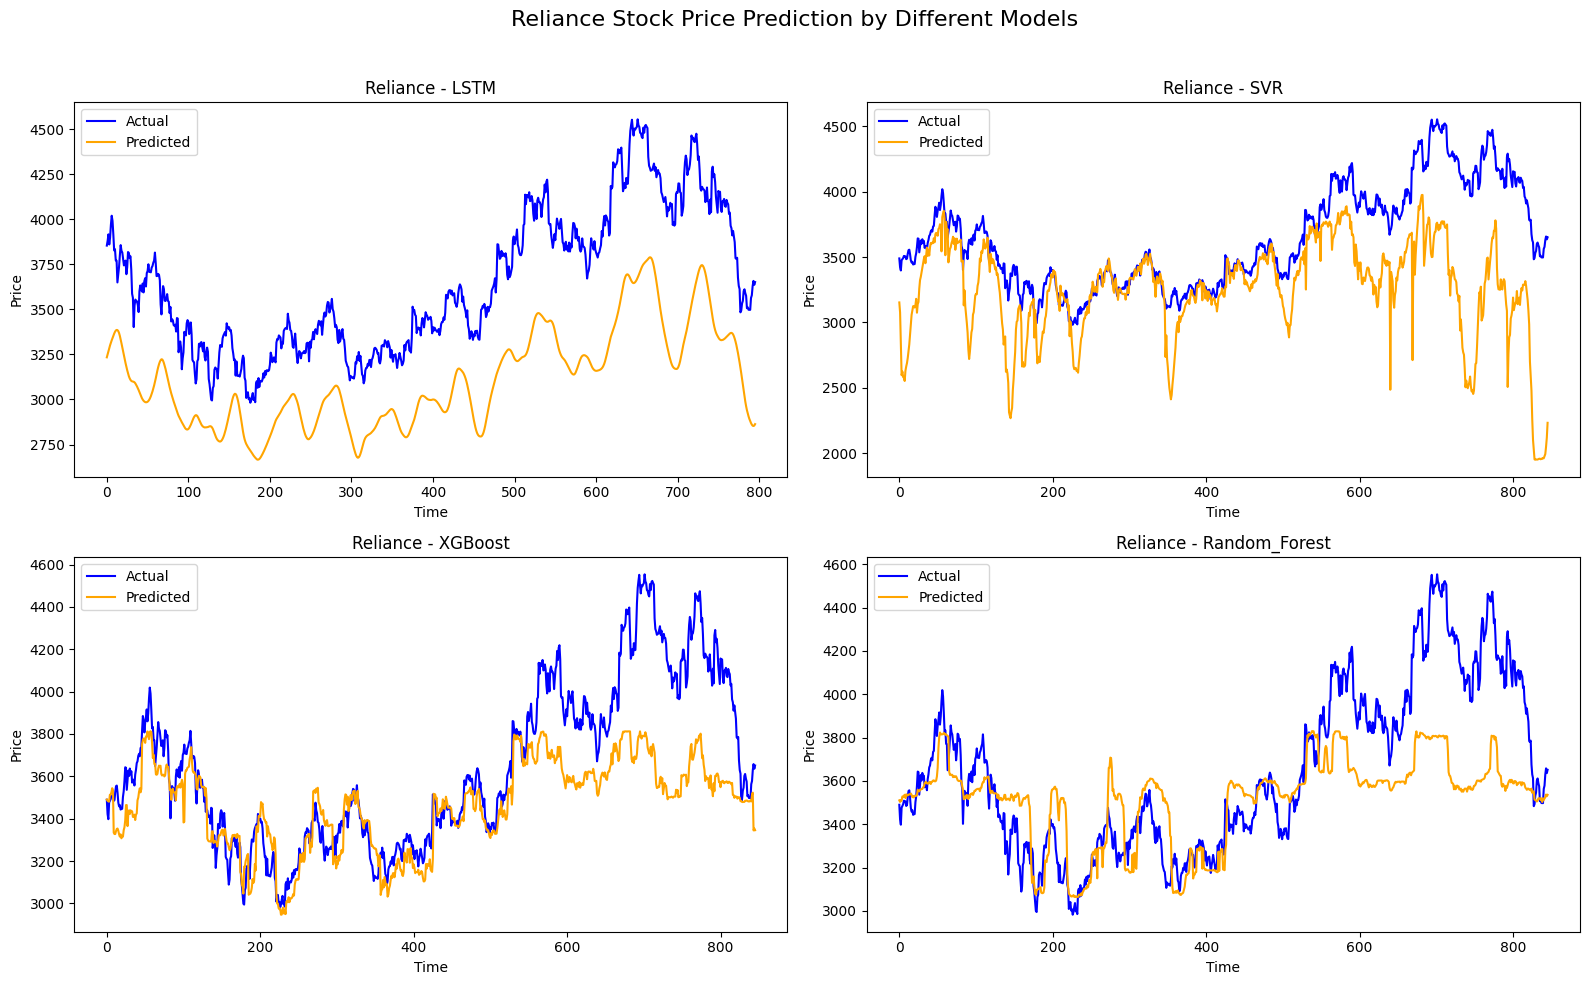

         LSTM       SVR   XGBoost  Random_Forest
MAE  0.139100  0.474919  0.247540       0.264350
MSE  0.021390  0.466899  0.123512       0.127011
R2  -1.054914 -1.234531  0.408883       0.392140

--- Running Models for HDFC Bank ---
Epoch 1/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0891 - val_loss: 0.0371
Epoch 2/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0281 - val_loss: 0.0171
Epoch 3/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0123 - val_loss: 0.0134
Epoch 4/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0072 - val_loss: 0.0084
Epoch 5/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0050 - val_loss: 0.0102
Epoch 6/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0036 - val_loss: 0.0070
Epoch 7/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0028 - val_loss: 0.0092
Epoch 8/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0022 - val_loss: 0.0062
Epoch 9/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0019 - val_loss: 0.0061
E

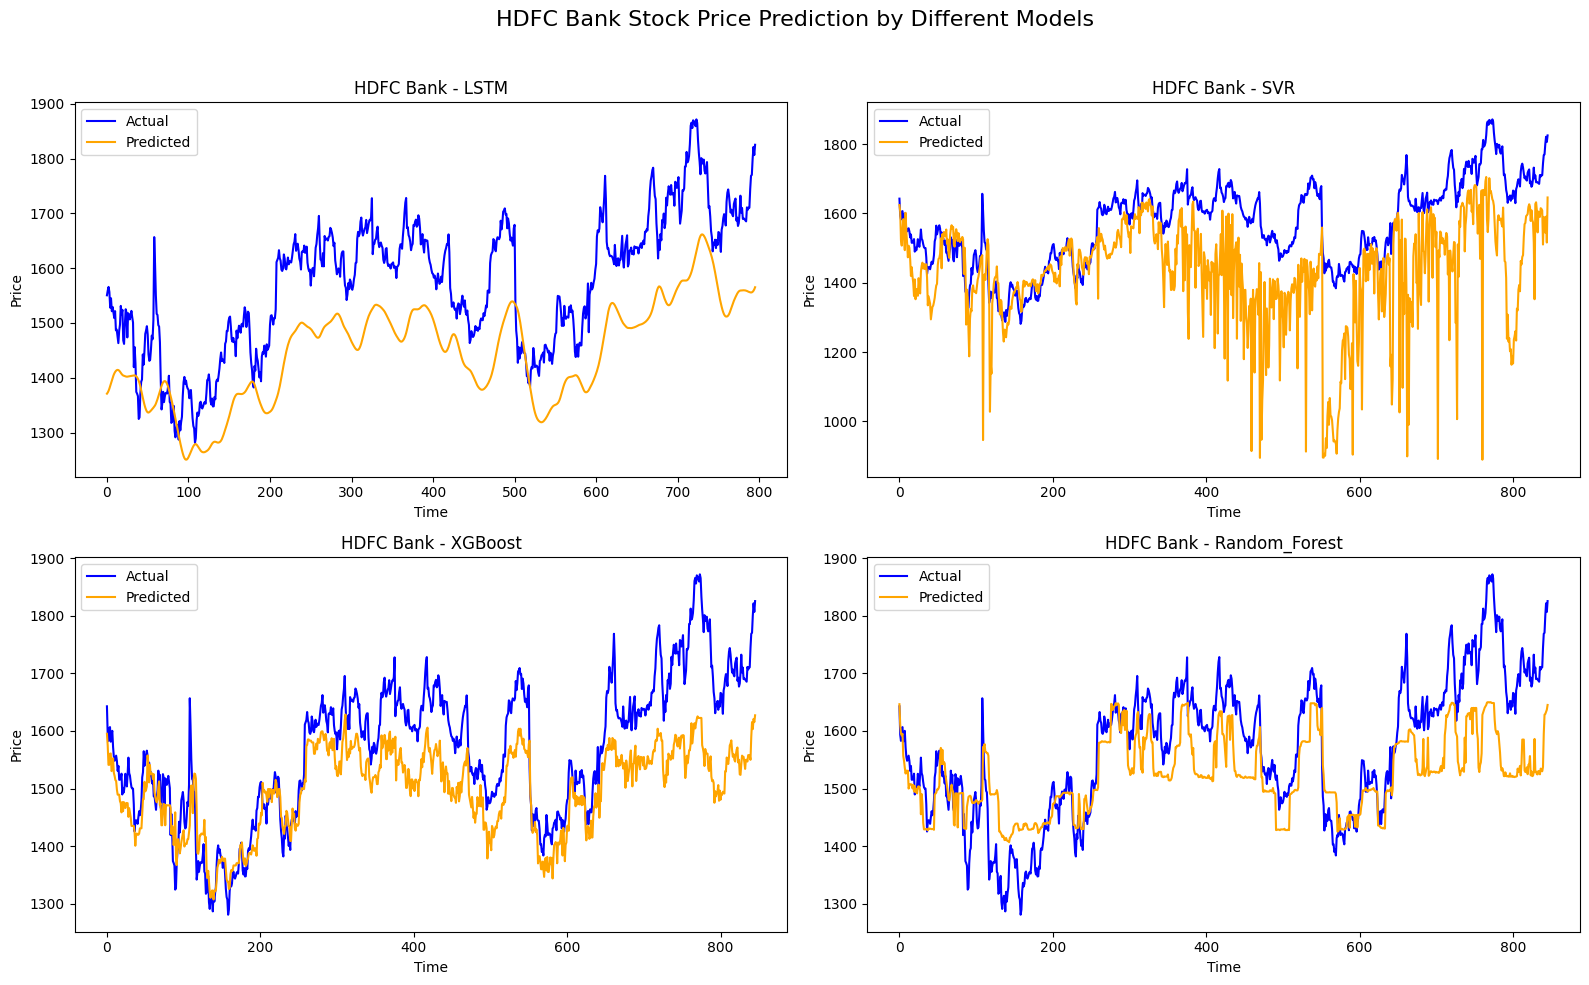

         LSTM       SVR   XGBoost  Random_Forest
MAE  0.079154  0.356016  0.180628       0.164151
MSE  0.007527  0.233891  0.049393       0.042742
R2  -0.289277 -1.910116  0.385441       0.468198

--- Running Models for TCS ---
Epoch 1/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0848 - val_loss: 0.0388
Epoch 2/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0245 - val_loss: 0.0158
Epoch 3/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0095 - val_loss: 0.0146
Epoch 4/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0051 - val_loss: 0.0086
Epoch 5/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0033 - val_loss: 0.0041
Epoch 6/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0023 - val_loss: 0.0060
Epoch 7/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0017 - val_loss: 0.0031
Epoch 8/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014 - val_loss: 0.0037
Epoch 9/80
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - val_loss: 0.0033
Epoch 1

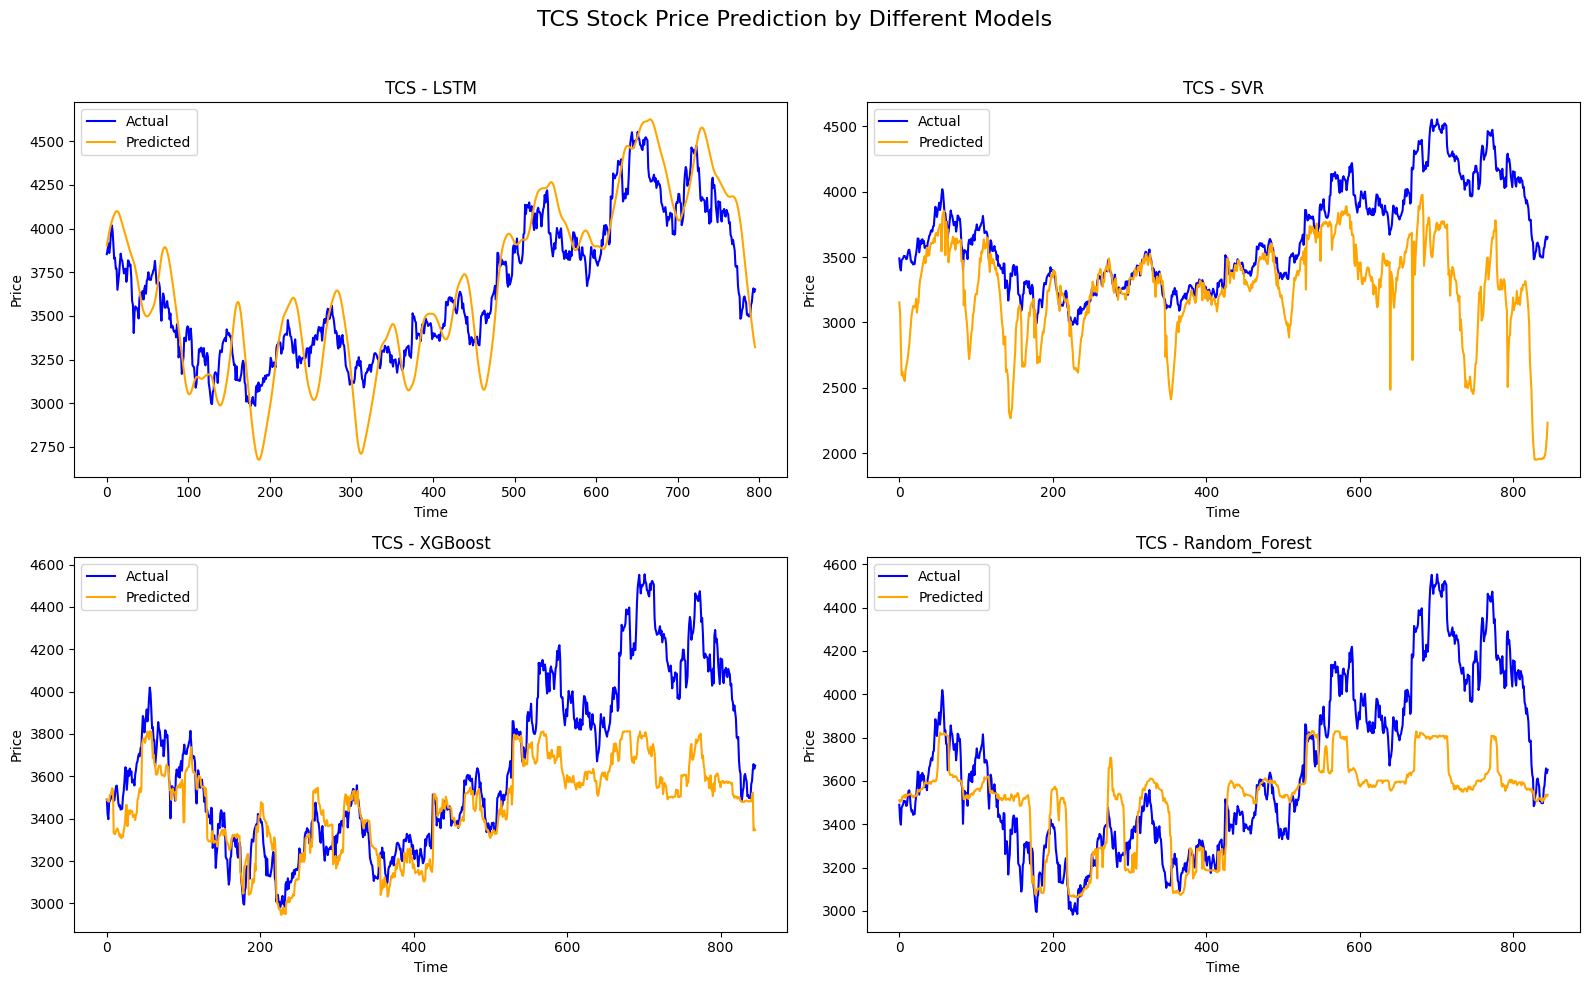

         LSTM       SVR   XGBoost  Random_Forest
MAE  0.045981  0.474919  0.247540       0.264350
MSE  0.003033  0.466899  0.123512       0.127011
R2   0.708662 -1.234531  0.408883       0.392140


In [ ]:
all_results = {}
for name, df in stocks.items():
    print(f"\n--- Running Models for {name} ---")
    results = train_and_evaluate(df, name)
    all_results[name] = results
    print(pd.DataFrame(results))